<a href="https://colab.research.google.com/github/hannaginther/ENGG680_2025_Fall/blob/Allison/MLTest_CorrelationData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

#Loading Data
path = "/content/drive/MyDrive/sparcs_model_v1.feather"
data = pd.read_feather(path)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#Looking at the Dataset Info
print(data.shape)
data.info()
data.head()

(4238636, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238636 entries, 0 to 4238635
Data columns (total 33 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   health_service_area      object 
 1   hospital_county          object 
 2   facility_id              object 
 3   age_group                object 
 4   zip_code                 object 
 5   gender                   object 
 6   race                     object 
 7   ethnicity                object 
 8   length_of_stay           int64  
 9   admission_type           object 
 10  disposition              object 
 11  discharge_year           int64  
 12  ccsr_dx_code             object 
 13  ccsr_px_code             object 
 14  apr_drg_code             object 
 15  apr_mdc_code             object 
 16  apr_severity_code        object 
 17  apr_mortality_risk       object 
 18  apr_med_surg_desc        object 
 19  total_charges            float64
 20  payer_medicaid           int64  

,health_service_area,hospital_county,facility_id,age_group,zip_code,gender,race,ethnicity,length_of_stay,admission_type,...,payer_self_pay,payer_blue_cross,payer_other,payer_gov_va,payer_corrections,payer_managed_care,num_payment_types,log_total_charges,los_log,los_yj
0,New York City,Bronx,3058,50-69,104,F,Other Race,Spanish/Hispanic,1,Emergency,...,0,0,0,0,0,0,1,10.217627,0.693147,-1.501001
1,New York City,Bronx,1168,30-49,104,M,Black/African American,Not Span/Hispanic,4,Emergency,...,0,0,0,0,0,0,1,11.322140,1.609438,0.246954
2,New York City,Bronx,3058,50-69,104,M,Other Race,Not Span/Hispanic,4,Emergency,...,0,0,0,0,0,0,2,11.241267,1.609438,0.246954
3,New York City,Bronx,1169,18-29,104,M,Black/African American,Not Span/Hispanic,5,Emergency,...,0,0,0,0,0,0,1,11.258467,1.791759,0.503353
4,New York City,Bronx,1169,50-69,104,F,Other Race,Spanish/Hispanic,3,Emergency,...,0,0,0,0,0,0,2,11.057713,1.386294,-0.103046


In [2]:
drop_columns=['disposition', 'discharge_year', 'ccsr_px_cod', 'apr_med_surg_desc']

float_columns = ['log_total_charges', 'los_log', 'los_yj']

categorical_cols = ['zip_code', 'health_service_area', 'facility_id', 'hospital_county', 'age_group',
                    'gender', 'race', 'ethnicity', 'admission_type', 'apr_mortality_risk',
                    'apr_severity_code', 'apr_drg_code', 'apr_mdc_code', 'ccsr_dx_code']

numeric_cols = ['payer_medicaid', 'payer_medicare','payer_private_insurance','payer_self_pay',
                'payer_blue_cross','payer_other', 'payer_gov_va',
                'payer_corrections','payer_managed_care','num_payment_types']

In [3]:
#Creating a function to clean and prepare data set
def clean_data(df):

#Remove Duplicates
  df = df.drop_duplicates()

#Excluding the rows that do not have LOS; Missing data
  df = df.dropna(subset = ['length_of_stay'])

#Convert data to numerical, Drop those who can't convert
  df['length_of_stay'] = pd.to_numeric(df['length_of_stay'], errors='coerce')
  df = df.dropna(subset = ['length_of_stay'])

#Remove out-of-state ZIP Codes ('OOS')
  if 'Zip Code' in df.columns:
      df = df[df['zip_code'] != 'OOS']

  df = df.drop(columns =[c for c in drop_columns if c in df.columns], errors = 'ignore')

  return df

#Clean Data
data = clean_data(data)

print("Shape of cleaned data:", data.shape)  # rows, columns




Shape of cleaned data: (4206911, 30)


,total_charges,payer_medicaid,payer_medicare,payer_private_insurance,payer_self_pay,payer_blue_cross,payer_other,payer_gov_va,payer_corrections,payer_managed_care,num_payment_types,log_total_charges,los_log,los_yj
count,4.206911e+06,4.206911e+06,4.206911e+06,4.206911e+06,4.206911e+06,4.206911e+06,4.206911e+06,4.206911e+06,4.206911e+06,4.206911e+06,4.206911e+06,4.206911e+06,4.206911e+06,4.206911e+06
mean,8.741505e+04,4.551686e-01,4.384597e-01,2.177664e-01,1.347423e-01,1.497973e-01,1.313220e-02,1.650475e-02,7.254729e-04,1.635048e-02,1.588125e+00,1.075193e+01,1.578865e+00,6.051117e-03
std,1.786041e+05,4.979862e-01,4.961984e-01,4.127278e-01,3.414482e-01,3.568727e-01,1.138409e-01,1.274062e-01,2.692484e-02,1.268193e-01,6.963310e-01,1.072658e+00,7.279715e-01,1.000634e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.931472e-01,-1.501001e+00
25%,2.316043e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.005024e+01,1.098612e+00,-6.208734e-01
50%,4.599531e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.073632e+01,1.386294e+00,-1.030461e-01
75%,9.181462e+04,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,1.142754e+01,1.945910e+00,7.013720e-01
max,2.568672e+07,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,1.706148e+01,4.795791e+00,2.498299e+00


length_of_stay             1.000000
los_log                    0.812399
los_yj                     0.674406
total_charges              0.660516
log_total_charges          0.530580
payer_medicare             0.090452
payer_medicaid             0.059585
num_payment_types          0.059088
payer_other                0.006569
payer_corrections          0.002052
payer_gov_va              -0.001735
payer_managed_care        -0.010792
payer_self_pay            -0.010948
payer_private_insurance   -0.043695
payer_blue_cross          -0.044510
Name: length_of_stay, dtype: float64


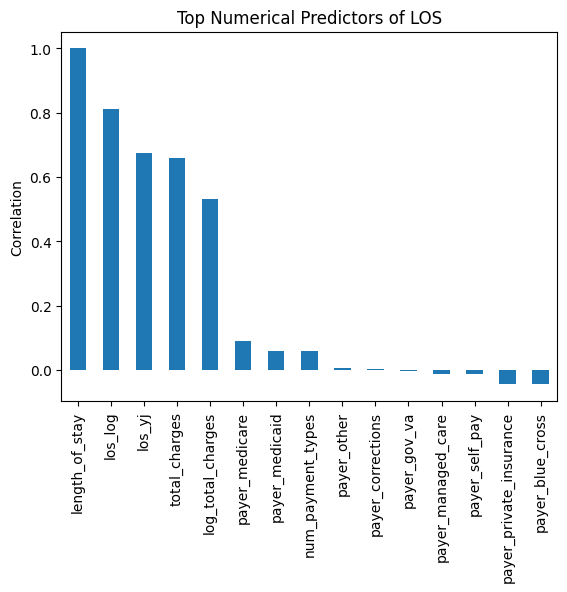

In [6]:
#CORRELATIONS FOR NUMERICAL DATA (INT64)

#Getting numerical columns (int + float)
numerical_columns = data.select_dtypes(include = ['int64', 'float64']).columns.tolist()

#Remove target variable from the predictor list
numerical_columns.remove('length_of_stay')
display(data[numerical_columns].describe())

#Calculate correlations between LOS and each numeric variable
correlations = (data[numerical_columns + ['length_of_stay']]
                .corr()['length_of_stay'].sort_values(ascending = False))
print(correlations)

correlations.head(15).plot(kind='bar')
plt.title("Top Numerical Predictors of LOS")
plt.ylabel("Correlation")
plt.show()

#DATA TAKEAWAYS

#Medicare - Slight positive correlation: patients with Medicare tend to have slightly longer stays. But still not very strong.
#More payment types associated with slightly longer stay, could indicate complex cases

#Payment indicators have very weak correlation with LOS, are not strong predictors


In [ ]:
#CORRELATIONS FOR CATERGORICAL DATA (object)

#One-hot encoded
data_encoded = pd.get_dummies(data[categorical_cols], drop_first=True)

#Add LOS for correlation
data_encoded['length_of_stay'] = data['length_of_stay']

#Calculate correlations between LOS and all one-hot encoded categorical variables
correlations_cat = data_encoded.corr()['length_of_stay'].sort_values(ascending=False)

print(correlations_cat)

#mean LOS per category, which categories have longer or shorter stays
for col in categorical_cols:
    print(f"\nAverage LOS by {col}:")
    print(data.groupby(col)['length_of_stay'].mean().sort_values(ascending=False).head(10))


#DATA TAKEAWAYS

#APR Risk of Mortality show the strongest relationship with LOS, especially:
#Extreme ~12.6 days on average, Minor ~3.9 days on average
#LOS increases sharply with mortality risk, which is expected clinically.

#Age Group shows older patients have longer stays:
#70 or Older 6.48 days
#0-17 3.92 days

#Race, some differences in LOS:
#Black/African American	6.62 days
#Multi-racial 5.61 days
#White	5.56 days
#Other Race	5.37 days

#ZIP code: some variation by area, but weaker effects

